In [1]:
import pandas as pd

In [2]:
processed_df = pd.read_csv("processed_laptops.csv")

In [3]:
processed_df['new'].unique()

array([1, 0])

In [4]:
processed_df.columns

Index(['brand', 'new', 'price', 'cpu_brand', 'cpu_tier', 'cpu_model',
       'cpu_suffix', 'gpu_brand', 'gpu_model', 'ram_size', 'ram_type',
       'storage_size', 'storage_type'],
      dtype='object')

In [5]:
use_case_weights = {
"general" : {
    "weights":{
        "cpu": 0.35,
        "ram": 0.35,
        "storage": 0.2,
        "gpu": 0.1
    },
    "min_score": 0.35
    },

"programming" : {
    "weights":{"cpu": 0.45,
    "ram": 0.3,
    "storage": 0.15,
    "gpu": 0.1
    },
    "min_score": 0.5
    },

"design" : {
    "weights":{"gpu": 0.4,
    "ram": 0.3,
    "cpu": 0.2, 
    "storage": 0.1
    },
     "min_score": 0.6
    },

"gaming" : {
    "weights":{"gpu": 0.45,
    "cpu": 0.3,
    "ram": 0.2,
    "storage": 0.05},
     "min_score": 0.6
    }
}

In [6]:
use_case_weights['gaming']['weights']

{'gpu': 0.45, 'cpu': 0.3, 'ram': 0.2, 'storage': 0.05}

# GPU scoring

In [7]:
def extract_gpu_family(model):

    model = str(model).lower()

    if model.startswith("rtx"):
        return "rtx"

    elif model.startswith("gtx"):
        return "gtx"

    elif model.startswith("mx"):
        return "mx"

    elif model.startswith(("p", "t", "m")):
        return "quadro"

    elif model.startswith("wx"):
        return "quadro"

    elif model.startswith("arc") or model in ["140v", "140t"]:
        return "arc"

    elif "iris" in model:
        return "iris"

    elif model == "uhd":
        return "uhd"

    elif model.startswith("apple"):
        return "apple"

    elif model in ["610m", "560x", "8650g", "7400m", "r5"]:
        return "radeon"

    elif model.startswith("hd"):
        return "hd"

    else:
        return "unknown"

In [8]:
gpu_family = processed_df['gpu_model'].apply(lambda model: extract_gpu_family(model))
gpu_family.value_counts()

gpu_model
rtx        146
uhd         78
unknown     37
quadro      21
iris        12
mx           9
hd           9
radeon       7
arc          6
apple        5
Name: count, dtype: int64

In [9]:
tmp = processed_df[
    processed_df["gpu_model"].str.startswith('rtx') | processed_df["gpu_model"].str.startswith('mx') 
]['gpu_model'].copy()

In [10]:
"""
generaion : the first digit after RTX
RTX2050 -> 2 
RTX3050 -> 3
RTX4060 -> 4
RTX5070 -> 5

Tier : last two digits are the tier
RTX2050 : 50 -> 1 
60 -> 2
70 -> 3
80 -> 4
90 -> 5

"""

import re

def extract_nvidia_scores(model):
    
    digits = re.findall(r"\d+", model)

    if not digits:
        return None, None

    number = digits[0]

    generation_score = int(number[0])

    tier = int(number[2:])

    tier_score = (tier // 10) - 4

    return generation_score, tier_score

In [11]:
print(extract_nvidia_scores("rtx2050"))
print(extract_nvidia_scores("rtx3050"))
print(extract_nvidia_scores("rtx4060"))
print(extract_nvidia_scores("rtx5070"))

(2, 1)
(3, 1)
(4, 2)
(5, 3)


In [12]:
family_scores = {
    "rtx": 10,
    "gtx": 8,
    "rx":9,
    "quadro": 7,

    "arc": 7,

    "apple": 6,

    "mx": 5,

    "iris": 4,
    "radeon": 4,

    "uhd": 2,
    "hd": 1,

    "unknown": 0
}


In [13]:
#gpu_score = 10 +generation_score + tier_score
# TODO: handle gtx 3 digits ex: gtx960
def gpu_score(gpu):
    family = extract_gpu_family(gpu)
    if family in ['rtx', 'gtx']:
        generation_score, tier_score = extract_nvidia_scores(gpu)
        result =  family_scores[family] + generation_score + tier_score
    elif family == 'mx':
        generation_score, tier_score = extract_nvidia_scores(gpu)
        result = family_scores[family] + generation_score
    else:
        result = family_scores[family]
    return  result 

processed_df['gpu_score'] = processed_df['gpu_model'].apply(gpu_score)
processed_df.head(2)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,ram_type,storage_size,storage_type,gpu_score
0,ASUS,1,335,intel,i3,305,unknown,intel,uhd,8,ddr4,256,ssd,2
1,ASUS,1,360,intel,i3,1315,u,intel,uhd,8,ddr4,512,ssd,2


End of gpu Scoring

# CPU scoring:

In [14]:
cpu_family_scores = {
    # Very Low
    "atom": 1,
    "a1": 1,
    "a6": 1,
    "a8": 1,

    # Low
    "celeron": 2,
    "athlon silver": 2,
    "n100": 2,

    # Entry
    "i3": 4,
    "core 3": 4,
    "ryzen 3": 4,

    # Mid
    "i5": 6,
    "core 5": 6,
    "ryzen 5": 6,

    # High
    "i7": 8,
    "core 7": 8,
    "ryzen 7": 8,

    # Enthusiast
    "i9": 10,
    "ultra 9": 10,
    "ryzen 9": 10,

    # Special
    "ultra 5": 7,
    "ultra 7": 9,

    "xeon": 8,

    "m1": 8,
    "m2": 9,
    "m3": 10,

    "x plus": 8
}

In [15]:
suffix_scores = {
    "unknown": 0,

    "g1": 1,
    "g7": 1,

    "u": 2,

    "h": 4,
    "hq": 4,
    "hs": 4,

    "hk": 5,
    "hx": 6,

    "pro": 3,

    "m": 5,

    "ultra": 4
}


In [16]:
processed_df["cpu_model"].unique()

array([  305,  1315,  7445,  1335, 42100,  1355,  7435,   210, 13620,
       14650,   720,  9955,   275,  8940, 14900,     0,  1334,   120,
       13420,   150,  4500,  7520,  7235, 12450, 13450, 12650, 13650,
       13700,   250,   260, 14700, 13500, 13900, 12420,  1165,   256,
         255,   225,   226, 11800, 10500,   240,   100,   185,  8945,
        6900,  7320,  7260,  7840,  5800, 12600,   125, 10210,  3700,
        1305,  9400,  2276,  9850,  8850,  6820,  9750,  4650,  6500,
        6200,  4300,  6300,  6600, 73000,  3865, 10110,  1215,  1255,
        7050,  8265,  6100, 10875,  7120,  3500,  9880,     2,     3,
           1,   155,  7730,  6410,  5750, 10850,  2450,  1035,   475,
        7820,  8750,  1185,  4600,  1545,  1135,   520,   285,  4260,
        3561,  1145])

In [17]:
def intel_generation_score(model):

    model = int(model)

    if model >= 14000:
        return 5

    elif model >= 13000:
        return 4

    elif model >= 12000:
        return 3

    elif model >= 10000:
        return 2

    else:
        return 1

In [18]:
def amd_generation_score(model):

    model = int(model)

    if model >= 9000:
        return 5

    elif model >= 7000:
        return 4

    elif model >= 5000:
        return 3

    else:
        return 2

In [19]:
def cpu_score(row):

    family = cpu_family_scores[row["cpu_tier"]]

    suffix = suffix_scores[row["cpu_suffix"]]

    generation = 0

    if row["cpu_brand"]== "intel":
        generation = intel_generation_score(
            row["cpu_model"]
        )

    elif row["cpu_brand"] == "amd":
        generation = amd_generation_score(
            row["cpu_model"]
        )

    return (family + generation + suffix)

In [20]:
tmp = processed_df.sample(1)
print(tmp)
print("*"*10)
print("score = ", tmp.apply(cpu_score, axis=1))

      brand  new  price cpu_brand cpu_tier  cpu_model cpu_suffix gpu_brand  \
135  Lenovo    1   1175       amd  ryzen 7       7840         hs    nvidia   

    gpu_model  ram_size ram_type  storage_size storage_type  gpu_score  
135   rtx4060        16     ddr5           512          ssd         16  
**********
score =  135    16
dtype: int64


In [21]:
processed_df["cpu_score"] = (
    processed_df.apply(cpu_score, axis=1)
)

In [22]:
processed_df['cpu_score'].describe()

count    330.000000
mean      12.490909
std        4.154491
min        2.000000
25%        9.000000
50%       12.500000
75%       16.000000
max       21.000000
Name: cpu_score, dtype: float64

In [23]:
processed_df[
    ["cpu_tier", "cpu_model", "cpu_suffix", "cpu_score"]
].sort_values("cpu_score", ascending=False).head(20)

,cpu_tier,cpu_model,cpu_suffix,cpu_score
20,i9,14900,hx,21
17,ryzen 9,9955,hx,21
131,i9,14900,hx,21
115,i9,14900,hx,21
114,ryzen 9,9955,hx,21
187,i9,14900,hx,21
54,i9,14900,hx,21
245,ryzen 9,8940,hx,20
19,ryzen 9,8940,hx,20
21,ryzen 9,8940,hx,20


In [24]:
processed_df[
    ["cpu_tier", "cpu_model", "cpu_suffix", "cpu_score"]
].sort_values("cpu_score").head(20)

,cpu_tier,cpu_model,cpu_suffix,cpu_score
32,celeron,4500,unknown,2
259,atom,475,unknown,2
98,n100,100,unknown,3
99,celeron,4500,unknown,3
242,celeron,4500,unknown,3
243,a8,6410,unknown,4
25,i3,305,unknown,5
0,i3,305,unknown,5
96,i3,305,unknown,5
261,i3,305,unknown,5


In [25]:
# Ryzen 9 9955HX
test = pd.DataFrame({
    "cpu_tier": ["ryzen 9"],
    "cpu_model": ["9955"],
    "cpu_suffix": ["hx"],
    "cpu_brand": ["amd"]
})
cpu_score(test.iloc[0])

21

# RAM scoring

In [26]:
ram_size_scores = {
    0: 0,
    2: 1,
    4: 2,
    8: 4,
    12: 5,
    16: 7,
    24: 8,
    32: 9,
    64: 10
}
ram_type_scores ={
'ddr4':1,
'ddr5':2,
'ddr6':3,
'unknown':0
}

In [27]:
ram_size_scores[4]

2

In [28]:
def ram_score(row):
    size = row['ram_size']
    rtype = row['ram_type']
    return (ram_size_scores[size] + ram_type_scores[rtype])

In [29]:
ram_test = pd.DataFrame({"ram_size":[4],
                         "ram_type":['ddr4']})
ram_score(ram_test.loc[0])

3

# Storage scoring

In [30]:
print(processed_df['storage_size'].unique())
print(10*'*')
print(processed_df['storage_type'].unique())

[ 256  512 1000 2000    0  128  500]
**********
['ssd' 'hdd' 'unknown']


In [31]:
storage_size_scores = {
0: 0,
128: 1,
256: 2,
512: 4,
500: 4,
1024: 7,
1000: 7,
2000: 9,
2048: 9,
4096: 10
}
storage_type_scores = {
'ssd': 2,
'hdd': 0,
'unknown':0
}

In [32]:
def storage_score(row):
    size = row['storage_size']
    stype = row['storage_type']
    return (storage_size_scores[size] + storage_type_scores[stype])

In [33]:
storage_test = pd.DataFrame({"storage_size":[512], 
                             "storage_type":['ssd']})
storage_score(storage_test.loc[0])

6

In [34]:
processed_df['storage_score'] = processed_df.apply(storage_score, axis=1)
processed_df['ram_score'] = processed_df.apply(ram_score, axis=1)

# using the engine

In [35]:
def gaming_score(row):
    return (
        0.4 * row["gpu_score"] +
        0.3 * row["cpu_score"] +
        0.3 * row["ram_score"] 
    )

def design_score(row):
    return (
        0.4 * row["gpu_score"] +
        0.3 * row["cpu_score"] +
        0.3 * row["ram_score"] 
    )

def programming_score(row):
    return (
        0.4 * row["cpu_score"] +
        0.3 * row["ram_score"] +
        0.2 * row["storage_score"] +
        0.1 * row["gpu_score"]
    )

In [36]:
processed_df['gaming_score'] = processed_df.apply(gaming_score, axis=1)
processed_df['programming_score'] = processed_df.apply(programming_score, axis=1)

In [37]:
processed_df.loc[: , 'cpu_brand':'gaming_score'].head(20).sort_values('gaming_score', ascending=False)

,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,ram_type,storage_size,storage_type,gpu_score,cpu_score,storage_score,ram_score,gaming_score
19,amd,ryzen 9,8940,hx,nvidia,rtx5070,16,ddr5,1000,ssd,18,20,9,9,15.9
13,intel,i7,14650,hx,nvidia,rtx5060,32,ddr5,1000,ssd,17,19,9,11,15.8
17,amd,ryzen 9,9955,hx,nvidia,rtx5060,16,ddr5,1000,ssd,17,21,9,9,15.8
16,intel,i7,14650,hx,nvidia,rtx5070,16,ddr5,1000,ssd,18,19,9,9,15.6
14,intel,i7,14650,hx,nvidia,rtx5060,16,ddr5,1000,ssd,17,19,9,9,15.2
12,intel,i7,14650,hx,nvidia,rtx5050,16,ddr5,512,ssd,16,19,6,9,14.8
18,intel,ultra 9,275,ultra,nvidia,rtx5060,32,ddr5,1000,ssd,17,15,9,11,14.6
15,amd,ryzen 9,720,unknown,nvidia,rtx5070,32,ddr5,1000,ssd,18,12,9,11,14.1
11,intel,i7,13620,h,nvidia,rtx4050,16,ddr5,512,ssd,15,16,6,9,13.5
10,amd,ryzen 7,7445,hs,nvidia,rtx4050,16,ddr5,512,ssd,15,16,6,9,13.5


# test the engine

In [38]:
processed_df.groupby("gpu_model")["gaming_score"].mean().sort_values()

gpu_model
r5          4.000000
hd          4.300000
5170m       4.800000
unknown     4.875000
uhd         5.411538
8650g       5.500000
apple8      6.000000
7400m       6.400000
610m        6.600000
apple10     6.700000
irisxe      6.900000
mx130       7.050000
t720        7.300000
mx330       7.400000
p520        7.600000
p2000       7.600000
t600        7.600000
t2000       7.600000
p1000       7.750000
apple14     7.800000
mx570       7.900000
p600        7.900000
m620        7.900000
t1000       8.125000
m2          8.200000
p620        8.350000
mx450       9.000000
m2000       9.100000
p3000       9.100000
m1000       9.100000
arc         9.100000
m2200       9.100000
wx4150      9.100000
140t        9.250000
560x        9.400000
mx250       9.400000
140v        9.700000
arcg        9.700000
rtx4000     9.700000
rtx3000    10.200000
rtx2060    11.600000
rtx3060    12.000000
rtx2050    12.100000
rtx3050    12.228571
rtx4050    13.026923
rtx3070    13.200000
rtx5050    13.383333
rtx

In [39]:
processed_df.groupby('cpu_tier')['gaming_score'].mean().sort_values(ascending=False)

cpu_tier
ryzen 9          15.344444
ultra 9          14.487500
i9               13.918182
ryzen 7          12.114815
i7               10.745283
xeon              9.650000
ultra 7           9.514286
core 7            8.863636
i5                7.813433
ryzen 5           7.800000
m3                7.500000
ultra 5           7.087500
m1                6.900000
core 5            6.622222
m2                6.300000
x plus            5.500000
a1                5.500000
a6                4.800000
ryzen 3           4.700000
core 3            4.250000
athlon silver     4.200000
i3                4.024000
a8                4.000000
celeron           2.950000
n100              2.900000
atom              1.600000
Name: gaming_score, dtype: float64

In [40]:
processed_df[
    (processed_df["cpu_tier"].isin(["i3", "celeron", "atom"])) &
    (processed_df["gpu_score"] >= 14)
].sort_values("gaming_score", ascending=False)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,ram_type,storage_size,storage_type,gpu_score,cpu_score,storage_score,ram_score,gaming_score,programming_score


In [41]:
processed_df[
    (processed_df["cpu_tier"] == "xeon")
].sort_values("gaming_score", ascending=False)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,ram_type,storage_size,storage_type,gpu_score,cpu_score,storage_score,ram_score,gaming_score,programming_score
170,Dell,0,520,intel,xeon,2276,m,nvidia,rtx3000,16,ddr4,512,ssd,9,14,6,8,10.2,10.1
297,hp,0,300,intel,xeon,1545,m,nvidia,m1000,16,unknown,512,ssd,7,14,6,7,9.1,9.6


In [42]:
processed_df.sort_values(["gaming_score", "programming_score"], ascending=False)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,ram_type,storage_size,storage_type,gpu_score,cpu_score,storage_score,ram_score,gaming_score,programming_score
131,Lenovo,1,3550,intel,i9,14900,hx,nvidia,rtx4090,32,ddr5,1000,ssd,19,21,9,11,17.2,15.4
54,Lenovo,1,1950,intel,i9,14900,hx,nvidia,rtx5070,32,ddr5,1000,ssd,18,21,9,11,16.8,15.3
114,ASUS,1,2025,amd,ryzen 9,9955,hx,nvidia,rtx5070,16,ddr5,1000,ssd,18,21,9,9,16.2,14.7
187,Lenovo,1,1650,intel,i9,14900,hx,nvidia,rtx5070,16,ddr5,512,ssd,18,21,6,9,16.2,14.1
245,hp,1,1460,amd,ryzen 9,8940,hx,nvidia,rtx5060,32,ddr5,1000,ssd,17,20,9,11,16.1,14.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32,Lenovo,1,250,celeron,celeron,4500,unknown,intel,uhd,8,ddr4,256,ssd,2,2,4,5,2.9,3.3
98,hp,1,310,intel,n100,100,unknown,intel,uhd,4,ddr5,0,ssd,2,3,2,4,2.9,3.0
310,APPLE,0,175,intel,i5,4260,unknown,intel,unknown,4,unknown,128,ssd,0,7,3,2,2.7,4.0
99,hp,1,275,intel,celeron,4500,unknown,intel,uhd,4,ddr4,256,ssd,2,3,4,3,2.6,3.1


normalizing the scores

In [43]:
# x_norm = (x - x.min()) / (x.max() - x.min())
cpu_min, cpu_max = processed_df['cpu_score'].min(), processed_df['cpu_score'].max()
gpu_min, gpu_max = processed_df['gpu_score'].min(), processed_df['gpu_score'].max()
ram_min, ram_max = processed_df['ram_score'].min(), processed_df['ram_score'].max()
storage_min, storage_max = processed_df['storage_score'].min(), processed_df['storage_score'].max()

processed_df['cpu_score_norms'] = (processed_df['cpu_score'] - cpu_min) / (cpu_max - cpu_min)
processed_df['gpu_score_norms'] = (processed_df['gpu_score'] - gpu_min) / (gpu_max - gpu_min)
processed_df['ram_score_norms'] = (processed_df['ram_score'] - ram_min) / (ram_max - ram_min)
processed_df['storage_score_norms'] = (processed_df['storage_score'] - storage_min) / (storage_max - storage_min)

In [44]:
print(storage_min)
print(storage_max)


0
11


# building the final function for ranking

In [45]:
# parameters: row: the data row , weights: use_case_weight(gaming|general|programming|design)
def compute_performance_score(row, weights):
    return (
        weights['cpu'] * row["cpu_score_norms"] +
        weights['gpu'] * row["gpu_score_norms"] +
        weights['ram'] * row["ram_score_norms"] +
        weights['storage'] * row["storage_score_norms"]
    )


In [46]:
# TODO: we can vectorize the process to make it faster insted of apply
processed_df['gaming_score'] = processed_df.apply(lambda row: compute_performance_score(row, use_case_weights['gaming']['weights']), axis=1)
processed_df['programming_score'] =processed_df.apply(lambda row: compute_performance_score(row, use_case_weights['programming']['weights']), axis=1)
processed_df['design_score'] = processed_df.apply(lambda row: compute_performance_score(row, use_case_weights['design']['weights']), axis=1)
processed_df['general_score'] = processed_df.apply(lambda row: compute_performance_score(row, use_case_weights['general']['weights']), axis=1)

In [47]:
processed_df.sort_values('gaming_score', ascending=False).head(10)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,...,storage_score,ram_score,gaming_score,programming_score,cpu_score_norms,gpu_score_norms,ram_score_norms,storage_score_norms,design_score,general_score
131,Lenovo,1,3550,intel,i9,14900,hx,nvidia,rtx4090,32,...,9,11,0.990909,0.972727,1.000000,1.000000,1.000000,0.818182,0.981818,0.963636
54,Lenovo,1,1950,intel,i9,14900,hx,nvidia,rtx5070,32,...,9,11,0.967225,0.967464,1.000000,0.947368,1.000000,0.818182,0.960766,0.958373
114,ASUS,1,2025,amd,ryzen 9,9955,hx,nvidia,rtx5070,16,...,9,9,0.930861,0.912919,1.000000,0.947368,0.818182,0.818182,0.906220,0.894737
245,hp,1,1460,amd,ryzen 9,8940,hx,nvidia,rtx5060,32,...,9,11,0.927751,0.938517,0.947368,0.894737,1.000000,0.818182,0.929187,0.934689
187,Lenovo,1,1650,intel,i9,14900,hx,nvidia,rtx5070,16,...,6,9,0.917225,0.872010,1.000000,0.947368,0.818182,0.545455,0.878947,0.840191
19,ASUS,1,1775,amd,ryzen 9,8940,hx,nvidia,rtx5070,16,...,9,9,0.915072,0.889234,0.947368,0.947368,0.818182,0.818182,0.895694,0.876316
184,ASUS,1,1470,intel,i7,14650,hx,nvidia,rtx5060,32,...,9,11,0.911962,0.914833,0.894737,0.894737,1.000000,0.818182,0.918660,0.916268
13,ASUS,1,1420,intel,i7,14650,hx,nvidia,rtx5060,32,...,9,11,0.911962,0.914833,0.894737,0.894737,1.000000,0.818182,0.918660,0.916268
118,ASUS,1,1400,intel,i7,14650,hx,nvidia,rtx5060,32,...,9,11,0.911962,0.914833,0.894737,0.894737,1.000000,0.818182,0.918660,0.916268
67,hp,1,1475,intel,i7,14650,hx,nvidia,rtx5060,32,...,9,11,0.911962,0.914833,0.894737,0.894737,1.000000,0.818182,0.918660,0.916268


In [48]:
processed_df.groupby('cpu_tier')['gaming_score'].mean().sort_values(ascending=False)

cpu_tier
ryzen 9          0.883307
ultra 9          0.843840
i9               0.791562
ryzen 7          0.689093
i7               0.608450
ultra 7          0.546685
xeon             0.542584
core 7           0.505676
i5               0.435007
ryzen 5          0.430470
m3               0.422967
ultra 5          0.396352
m1               0.387799
core 5           0.371372
m2               0.352632
x plus           0.309330
a1               0.296172
a6               0.258373
ryzen 3          0.248804
core 3           0.235407
athlon silver    0.222010
i3               0.217435
a8               0.217225
celeron          0.156639
n100             0.144976
atom             0.060048
Name: gaming_score, dtype: float64

<Axes: >

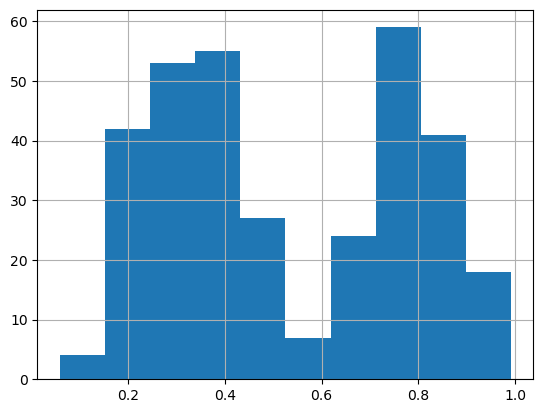

In [49]:
processed_df["gaming_score"].hist()

# testing

In [50]:
def compare_laptops(df, idx1, idx2, score_col="gaming_score"):
    a = df.loc[idx1]
    b = df.loc[idx2]

    print("A:")
    print(a[["cpu_tier", "gpu_model", "ram_size", "storage_size", score_col]])
    print("\nB:")
    print(b[["cpu_tier", "gpu_model", "ram_size", "storage_size", score_col]])

    if a[score_col] > b[score_col]:
        print("\n➡ Model chooses: A")
    elif a[score_col] < b[score_col]:
        print("\n➡ Model chooses: B")
    else:
        print("\n➡ Tie")

In [51]:
compare_laptops(processed_df, 45, 89)

A:
cpu_tier             i7
gpu_model       rtx3050
ram_size             16
storage_size        512
gaming_score    0.77512
Name: 45, dtype: object

B:
cpu_tier             i5
gpu_model       rtx3060
ram_size              8
storage_size        512
gaming_score    0.63134
Name: 89, dtype: object

➡ Model chooses: A


In [52]:
high_gpu = processed_df[processed_df["gpu_model"] == "rtx4090"].sample(1)
low_gpu = processed_df[processed_df["gpu_model"] == "rtx3050"].sample(1)

compare_laptops(processed_df, high_gpu.index[0], low_gpu.index[0])

A:
cpu_tier         ultra 9
gpu_model        rtx4090
ram_size              32
storage_size        2000
gaming_score    0.905263
Name: 108, dtype: object

B:
cpu_tier         ryzen 7
gpu_model        rtx3050
ram_size              16
storage_size         512
gaming_score    0.743541
Name: 123, dtype: object

➡ Model chooses: A


In [53]:
def pairwise_accuracy(df, n=100):
    correct = 0

    for _ in range(n):
        a = df.sample(1).iloc[0]
        b = df.sample(1).iloc[0]

        model_a = a["gaming_score"]
        model_b = b["gaming_score"]

        model_choice = "A" if model_a > model_b else "B"

        # ground truth proxy (simple rule)
        true_choice = "A" if a["gpu_score"] + a["cpu_score"] > b["gpu_score"] + b["cpu_score"] else "B"

        if model_choice == true_choice:
            correct += 1

    print("Pairwise agreement:", correct / n)

In [54]:
pairwise_accuracy(processed_df)

Pairwise agreement: 0.92


In [55]:
processed_df[['gaming_score','programming_score','design_score', 'general_score']].corr()

,gaming_score,programming_score,design_score,general_score
gaming_score,1.000000,0.940330,0.995916,0.939893
programming_score,0.940330,1.000000,0.944752,0.996096
design_score,0.995916,0.944752,1.000000,0.951557
general_score,0.939893,0.996096,0.951557,1.000000


In [56]:
processed_df[['gaming_score','programming_score','design_score']].std(axis=1).mean()

np.float64(0.047399640792886916)

In [57]:
processed_df.sample(1)

,brand,new,price,cpu_brand,cpu_tier,cpu_model,cpu_suffix,gpu_brand,gpu_model,ram_size,...,storage_score,ram_score,gaming_score,programming_score,cpu_score_norms,gpu_score_norms,ram_score_norms,storage_score_norms,design_score,general_score
244,Lenovo,0,155,amd,a1,5750,m,amd,8650g,8,...,4,4,0.296172,0.350478,0.368421,0.210526,0.363636,0.363636,0.303349,0.35


In [58]:
import numpy as np
def compute_value_score(performance_score, price):
    return performance_score / np.log1p(price)

In [59]:
processed_df["gaming_value"] = processed_df.apply(
    lambda row: compute_value_score(row["gaming_score"], row["price"]),
    axis=1
)

In [60]:
processed_df[
    ["brand","cpu_tier","cpu_model", "cpu_suffix","gpu_model" , "price", "gaming_score", "gaming_value"]
].sort_values(
    "gaming_value",
    ascending=False
).head(20)

,brand,cpu_tier,cpu_model,cpu_suffix,gpu_model,price,gaming_score,gaming_value
54,Lenovo,i9,14900,hx,rtx5070,1950,0.967225,0.127668
245,hp,ryzen 9,8940,hx,rtx5060,1460,0.927751,0.127318
118,ASUS,i7,14650,hx,rtx5060,1400,0.911962,0.125876
13,ASUS,i7,14650,hx,rtx5060,1420,0.911962,0.125630
184,ASUS,i7,14650,hx,rtx5060,1470,0.911962,0.125034
67,hp,i7,14650,hx,rtx5060,1475,0.911962,0.124976
3,ASUS,ryzen 7,7445,hs,rtx4050,465,0.767225,0.124870
21,ASUS,ryzen 9,8940,hx,rtx5060,1495,0.909569,0.124419
72,ASUS,i7,14650,hx,rtx5070,1420,0.899282,0.123883
187,Lenovo,i9,14900,hx,rtx5070,1650,0.917225,0.123796


# recommend engine

In [61]:
def recommend_laptops(df, budget, use_case, top_k=5):
    config = use_case_weights[use_case]
    weights = config['weights']
    min_score = config['min_score']

    candidate_df = df[df['price'] <= budget].copy()

    if candidate_df.empty:
        return None

    # calculate the performance
    candidate_df['performance'] = candidate_df.apply(lambda row: compute_performance_score(row, weights) ,axis =1)

    # filtering based on threshold 
    candidate_df = candidate_df[candidate_df['performance'] >= min_score].copy()

    # check if the df not empty after filtering
    if candidate_df.empty:
        return None

    # calculate the value 
    candidate_df['value'] = candidate_df.apply(lambda row: compute_value_score(row['performance'], row['price']), axis =1)

    # results
    best_performance = candidate_df.sort_values('performance', ascending =False).head(1)
    best_value = candidate_df.sort_values('value', ascending = False).head(1)
    top_k = candidate_df.sort_values("value", ascending=False).head(top_k)

    # return the results
    return{
        "best_performance": best_performance,
        "best_value": best_value,
        "top_k": top_k
        }

In [75]:
result = recommend_laptops(processed_df, 1000, 'gaming')
print('performance: ', result['best_performance'])
print(50*'*')
print('value: ', result['best_value'])
print(50*'*')
print(result['top_k'])


performance:       brand  new  price cpu_brand cpu_tier  cpu_model cpu_suffix gpu_brand  \
47  Lenovo    1    975     intel       i7      13650         hx    nvidia   

   gpu_model  ram_size  ... programming_score  cpu_score_norms  \
47   rtx4050        24  ...           0.81244         0.842105   

   gpu_score_norms  ram_score_norms  storage_score_norms  design_score  \
47        0.789474         0.909091             0.545455      0.811483   

    general_score  gaming_value  performance     value  
47       0.800957      0.118688     0.816986  0.118688  

[1 rows x 28 columns]
**************************************************
value:    brand  new  price cpu_brand cpu_tier  cpu_model cpu_suffix gpu_brand  \
3  ASUS    1    465       amd  ryzen 7       7445         hs    nvidia   

  gpu_model  ram_size  ... programming_score  cpu_score_norms gpu_score_norms  \
3   rtx4050        16  ...          0.737799         0.736842        0.789474   

   ram_score_norms  storage_score_norms  

# Testing the recommend engine

In [63]:
def test_recommendations(df, budgets, use_cases):
    
    results = {}

    for use_case in use_cases:
        for budget in budgets:

            res = recommend_laptops(
                df,
                budget=budget,
                use_case=use_case
            )

            if res is not None:
                results[(use_case, budget)] = {
                    "best_value": res["best_value"][["brand","cpu_tier","cpu_model","cpu_suffix", "gpu_model" , "price", "performance", "value"]],
                    "best_perf": res["best_performance"][["brand","cpu_tier","cpu_model","cpu_suffix", "gpu_model" , "price", "performance"]]
                }

    return results

In [64]:
use_cases = ["gaming", "programming", "design", "general"]
budgets = [400, 700, 1000, 1500]
test_results = test_recommendations(processed_df, budgets, use_cases)


In [65]:
test_results
# TODO: fix the best value to give more devices not and try to avoid the chepist one

{('gaming',
  700): {'best_value':   brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance    value
  3  ASUS  ryzen 7       7445         hs   rtx4050    465     0.767225  0.12487, 'best_perf':   brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance
  3  ASUS  ryzen 7       7445         hs   rtx4050    465     0.767225},
 ('gaming',
  1000): {'best_value':   brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance    value
  3  ASUS  ryzen 7       7445         hs   rtx4050    465     0.767225  0.12487, 'best_perf':      brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance
  47  Lenovo       i7      13650         hx   rtx4050    975     0.816986},
 ('gaming',
  1500): {'best_value':     brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance  \
  245    hp  ryzen 9       8940         hx   rtx5060   1460     0.927751   
  
          value  
  245  0.127318  , 'best_perf':     brand cpu_tier  cpu_model cpu_suffix gpu_model  pric

# Notes


In [66]:
cpu_family_scores

{'atom': 1,
 'a1': 1,
 'a6': 1,
 'a8': 1,
 'celeron': 2,
 'athlon silver': 2,
 'n100': 2,
 'i3': 4,
 'core 3': 4,
 'ryzen 3': 4,
 'i5': 6,
 'core 5': 6,
 'ryzen 5': 6,
 'i7': 8,
 'core 7': 8,
 'ryzen 7': 8,
 'i9': 10,
 'ultra 9': 10,
 'ryzen 9': 10,
 'ultra 5': 7,
 'ultra 7': 9,
 'xeon': 8,
 'm1': 8,
 'm2': 9,
 'm3': 10,
 'x plus': 8}

# 2026/6/17
# The plan is :
Explainability, 
Architecture (files), 
Test scenarios

In [67]:
processed_df.columns

Index(['brand', 'new', 'price', 'cpu_brand', 'cpu_tier', 'cpu_model',
       'cpu_suffix', 'gpu_brand', 'gpu_model', 'ram_size', 'ram_type',
       'storage_size', 'storage_type', 'gpu_score', 'cpu_score',
       'storage_score', 'ram_score', 'gaming_score', 'programming_score',
       'cpu_score_norms', 'gpu_score_norms', 'ram_score_norms',
       'storage_score_norms', 'design_score', 'general_score', 'gaming_value'],
      dtype='object')

In [80]:
test_results[('gaming', 1000)]

{'best_value':   brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance    value
 3  ASUS  ryzen 7       7445         hs   rtx4050    465     0.767225  0.12487,
 'best_perf':      brand cpu_tier  cpu_model cpu_suffix gpu_model  price  performance
 47  Lenovo       i7      13650         hx   rtx4050    975     0.816986}

In [76]:
# TODO: improvements (ordering + clarity + use-case awareness)
def generate_explanation(row):
    reasons = []

    # CPU
    cpu_score = row.get("cpu_score_norm", 0)
    if cpu_score > 0.7:
        reasons.append("Strong CPU performance suitable for heavy tasks")
    elif cpu_score > 0.4:
        reasons.append("Moderate CPU performance for general use")
    #############
    gpu_score = row.get("gpu_score_norm", 0)
    if gpu_score > 0.8:
        reasons.append("High-end GPU suitable for gaming and design")
    elif gpu_score > 0.5:
        reasons.append("Decent GPU for light gaming and graphics tasks")
    #############
    ram = row.get("ram_size", 0)
    if ram >= 32:
        reasons.append("Excellent RAM capacity for multitasking and heavy workloads")
    elif ram >= 16:
        reasons.append("Good RAM for most modern applications")
    else:
        reasons.append("Limited RAM, suitable for basic tasks")
    #############
    if row.get("storage_type") == "SSD":
        reasons.append("Fast SSD storage improves system responsiveness")
    else:
        reasons.append("HDD storage may reduce performance speed")
    ############
    price = row.get("price", 0)
    performance = row.get("performance", 0)

    if performance / (price + 1) > 0.05:
        reasons.append("Excellent performance-to-price ratio")
    elif performance / (price + 1) > 0.03:
        reasons.append("Balanced value for the price")
    else:
        reasons.append("Higher price relative to performance")
    ###########
    return reasons

In [81]:
print(generate_explanation(test_results[('gaming', 1000)]))

['Limited RAM, suitable for basic tasks', 'HDD storage may reduce performance speed', 'Higher price relative to performance']
